# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

FARS dataset (traffic fatalities)

who:  members of local, state, federal govenrment tasked with keeping their communities safe.

what:  deliver impactful figures that show or suggest laws that need to be implemented to reduce traffic fatalities and property loss.

how:  via slide deck, in-depth report, or in person testimony.

# 3. Homework - work with your own data

In [46]:

!pip install pandas
import pandas as pd
import numpy as np
from datetime import datetime, timedelta


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [47]:
df = pd.read_csv("accident.csv", low_memory=False)
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 37654 entries, 0 to 37653
Data columns (total 80 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   STATE         37654 non-null  int64  
 1   STATENAME     37654 non-null  str    
 2   ST_CASE       37654 non-null  int64  
 3   PEDS          37654 non-null  int64  
 4   PERNOTMVIT    37654 non-null  int64  
 5   VE_TOTAL      37654 non-null  int64  
 6   VE_FORMS      37654 non-null  int64  
 7   PVH_INVL      37654 non-null  int64  
 8   PERSONS       37654 non-null  int64  
 9   PERMVIT       37654 non-null  int64  
 10  COUNTY        37654 non-null  int64  
 11  COUNTYNAME    37654 non-null  str    
 12  CITY          37654 non-null  int64  
 13  CITYNAME      37654 non-null  str    
 14  MONTH         37654 non-null  int64  
 15  MONTHNAME     37654 non-null  str    
 16  DAY           37654 non-null  int64  
 17  DAYNAME       37654 non-null  int64  
 18  DAY_WEEK      37654 non-null  int64  

,STATE,ST_CASE,PEDS,PERNOTMVIT,VE_TOTAL,VE_FORMS,PVH_INVL,PERSONS,PERMVIT,COUNTY,...,LGT_COND,WEATHER,SCH_BUS,NOT_HOUR,NOT_MIN,ARR_HOUR,ARR_MIN,HOSP_HR,HOSP_MN,FATALS
count,37654.000000,37654.000000,37654.000000,37654.000000,37654.000000,37654.000000,37654.000000,37654.000000,37654.000000,37654.000000,...,37654.000000,37654.000000,37654.000000,37654.000000,37654.000000,37654.000000,37654.000000,37654.000000,37654.000000,37654.000000
mean,27.304350,273893.087375,0.246640,0.258751,1.588809,1.548813,0.039996,2.207282,2.195172,92.568837,...,1.982286,6.082116,0.003081,58.696925,68.086339,60.323259,69.367690,76.548282,80.071493,1.086233
std,16.490819,164823.148700,0.492486,0.523579,0.842440,0.803674,0.282445,1.691668,1.684175,98.855373,...,1.215709,18.709699,0.055419,43.164030,36.384085,43.005261,36.158108,33.463910,28.068737,0.353643
min,1.000000,10001.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,12.000000,121977.500000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,31.000000,...,1.000000,1.000000,0.000000,15.000000,33.000000,15.000000,35.000000,88.000000,88.000000,1.000000
50%,27.000000,270059.500000,0.000000,0.000000,1.000000,1.000000,0.000000,2.000000,2.000000,71.000000,...,2.000000,1.000000,0.000000,99.000000,98.000000,99.000000,98.000000,88.000000,88.000000,1.000000
75%,42.000000,420770.750000,0.000000,0.000000,2.000000,2.000000,0.000000,3.000000,3.000000,115.000000,...,3.000000,2.000000,0.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,1.000000
max,56.000000,560121.000000,19.000000,19.000000,35.000000,35.000000,9.000000,52.000000,52.000000,999.000000,...,9.000000,99.000000,1.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,8.000000


In [48]:
df.duplicated().sum()

np.int64(0)

In [49]:
#mean, median, mode of each column
summary_stats = pd.DataFrame({
    "Mean": df.mean(numeric_only=True),
    "Median": df.median(numeric_only=True),
    "Mode": df.mode().iloc[0]})

summary_stats

,Mean,Median,Mode
ARR_HOUR,60.323259,99.0,99.0
ARR_HOURNAME,NaN,NaN,Unknown EMS Scene Arrival Hour
ARR_MIN,69.367690,98.0,99.0
ARR_MINNAME,NaN,NaN,Unknown EMS Scene Arrival Minutes
CITY,1380.101078,200.0,0.0
...,...,...,...
WEATHER,6.082116,1.0,1.0
WEATHERNAME,NaN,NaN,Clear
WRK_ZONE,0.042917,0.0,0.0
WRK_ZONENAME,NaN,NaN,Construction


In [50]:
df["WEATHER"].value_counts().sort_index()

WEATHER
1     27872
2      2650
3        45
4       222
5       399
6        44
7         9
8        35
10     4868
11       36
12       17
98     1304
99      153
Name: count, dtype: int64

In [51]:
df["CITY"].value_counts().sort_index()

CITY
0       17380
2           4
3           3
4           2
5           4
        ...  
9650        3
9800        1
9898      434
9997      238
9999        5
Name: count, Length: 2169, dtype: int64

In [52]:
df["DAY"].value_counts().sort_index()

DAY
1     1379
2     1208
3     1298
4     1377
5     1222
6     1239
7     1239
8     1290
9     1229
10    1161
11    1238
12    1164
13    1208
14    1240
15    1251
16    1204
17    1276
18    1215
19    1203
20    1201
21    1300
22    1303
23    1240
24    1184
25    1166
26    1233
27    1143
28    1218
29    1168
30    1186
31     671
Name: count, dtype: int64

In [53]:
df["HOUR"].value_counts().sort_index()

HOUR
0     1480
1     1361
2     1434
3     1122
4     1025
5     1269
6     1349
7     1160
8      939
9      991
10    1109
11    1152
12    1397
13    1451
14    1724
15    1794
16    1854
17    2099
18    2237
19    2194
20    2307
21    2280
22    1978
23    1666
99     282
Name: count, dtype: int64

In [54]:
df["MINUTE"].value_counts().sort_index()

MINUTE
0     1746
1      470
2      493
3      472
4      542
      ... 
56     459
57     515
58     517
59     453
99     282
Name: count, Length: 61, dtype: int64

MISSING DATA:

the WEATHER column definitely has some missing data:  code 98 is used for: not reported and code 99 is used for:  Unknown/Reports as Unknown (since 2018).   i would likely remove these rows from data analysis.   i would be removing 1457 out of 37654 rows (3.8%).

the CITY column also has missing data as code 9898 corresponds to not reported and code 9999 corresponds to Unknown and code 9997 corresponds to Not Reported.   i would probably remove these rows as well.

the DAY column looks fine wrt missing data.

the HOUR (and MINUTE) column looks like it has 282 rows with code 99:   Unknown.   the time of 0 in the minute column is much larger than other minute marks so I'd guess that would just be lazy data entry on scene where the officer doens't want to take the time to note the actual minute.

based on the histograms below the following columns also need some attention due to missing values that are encoded as high codes:  RD_OWNER, NHS, MILEPT, HOSP_MIN, ARR_HOUR, ARR_MIN, NOT_MIN, NOT_HOUR, HOSP_MIN


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


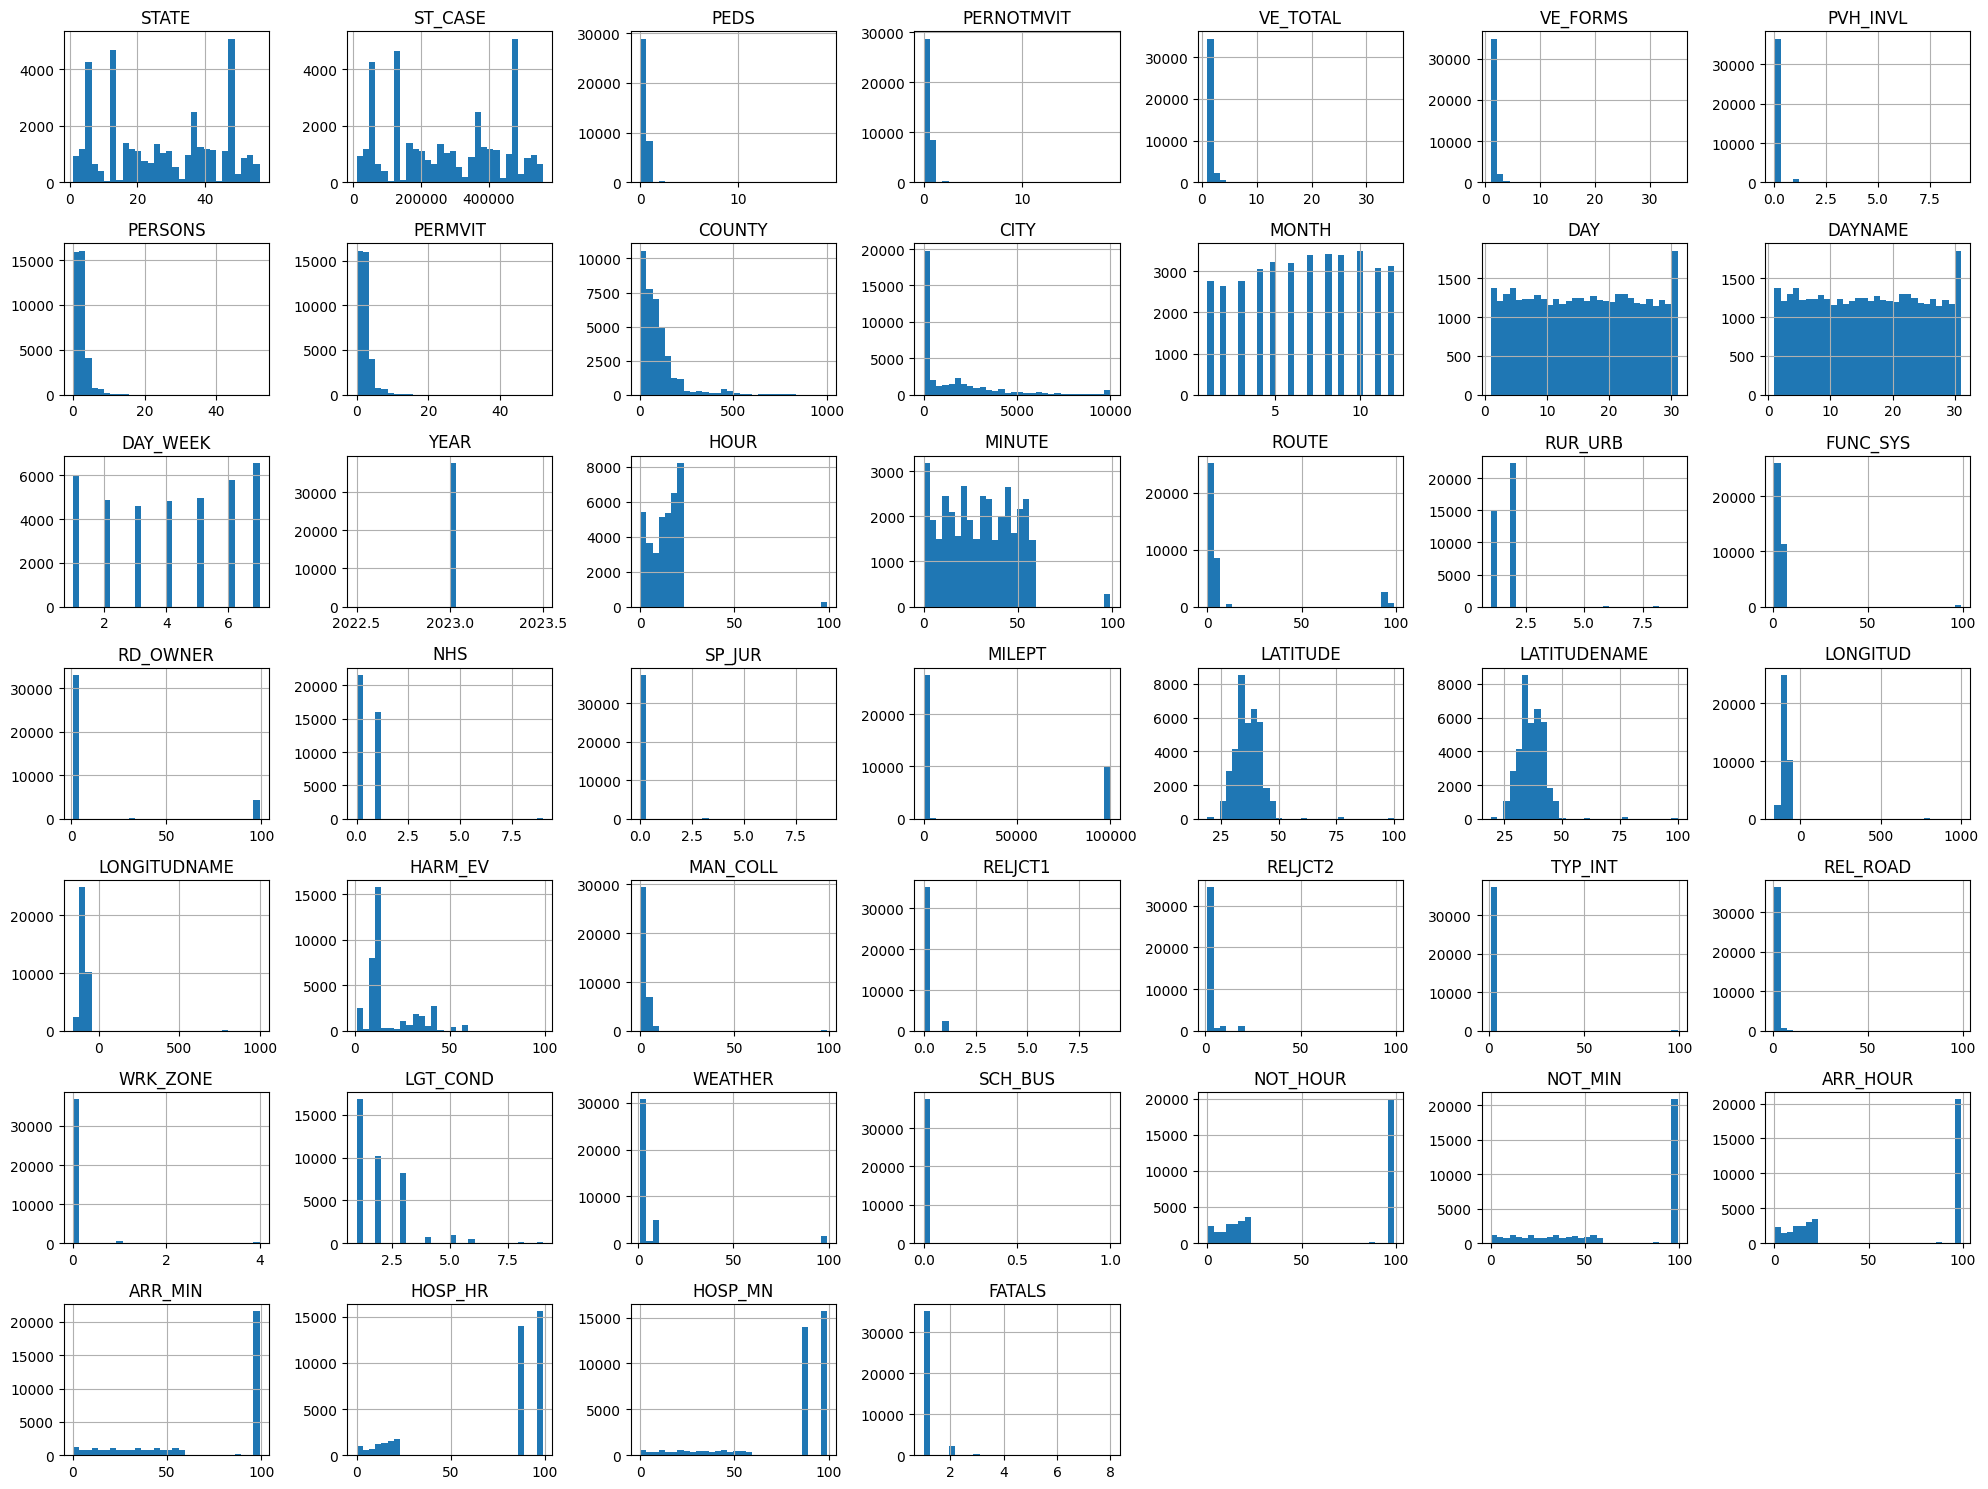

In [55]:
!pip install matplotlib
import matplotlib.pyplot as plt

df.hist(bins=30, figsize=(20, 15))

plt.tight_layout()
plt.show()

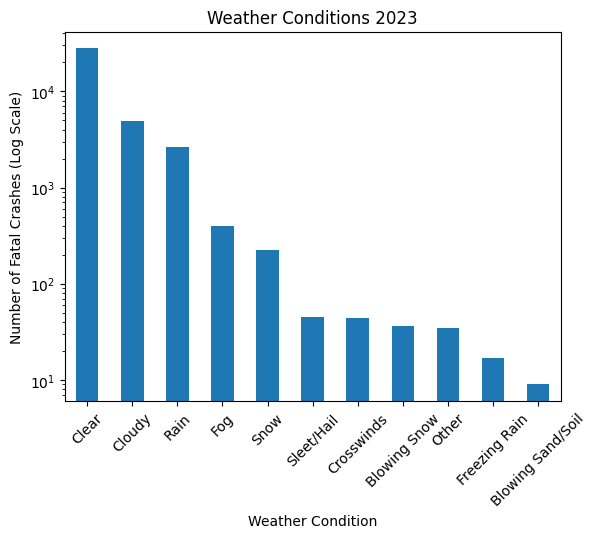

In [56]:
weather_labels = {
    1: "Clear",
    2: "Rain",
    3: "Sleet/Hail",
    4: "Snow",
    5: "Fog",
    6: "Crosswinds",
    7: "Blowing Sand/Soil",
    8: "Other",
    10: "Cloudy",
    11: "Blowing Snow",
    12: "Freezing Rain"}

df["WEATHER_LABEL"] = df["WEATHER"].map(weather_labels)

weather_counts = df["WEATHER_LABEL"].value_counts()

plt.figure()
weather_counts.plot(kind="bar")

plt.yscale("log")

plt.title("Weather Conditions 2023")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Fatal Crashes (Log Scale)")
plt.xticks(rotation=45)

plt.show()

The weather column could be an ideal column for one hot encoding (though i did have to make the scale log due to the high count for th "clear" category).  though as seen below there is a substantial class imbalace in this variable, the majority of crashes occurred under clear conditions.  this imbalance should be taken into consideration as minority classes may be underrepresented in the data set.

In [57]:
weather_counts = df["WEATHER_LABEL"].value_counts()
weather_percent = df["WEATHER_LABEL"].value_counts(normalize=True) * 100
weather_percent

WEATHER_LABEL
Clear                77.000856
Cloudy               13.448628
Rain                  7.321049
Fog                   1.102301
Snow                  0.613310
Sleet/Hail            0.124320
Crosswinds            0.121557
Blowing Snow          0.099456
Other                 0.096693
Freezing Rain         0.046965
Blowing Sand/Soil     0.024864
Name: proportion, dtype: float64

Conclusions:

Data appear usable.
Some rows will have to be deleted due to missing values (usually codes 98,99 or those higher codes) or replaced w median/avg or something akin
Some columns such as weather could use encoding to use that data in modeling.

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

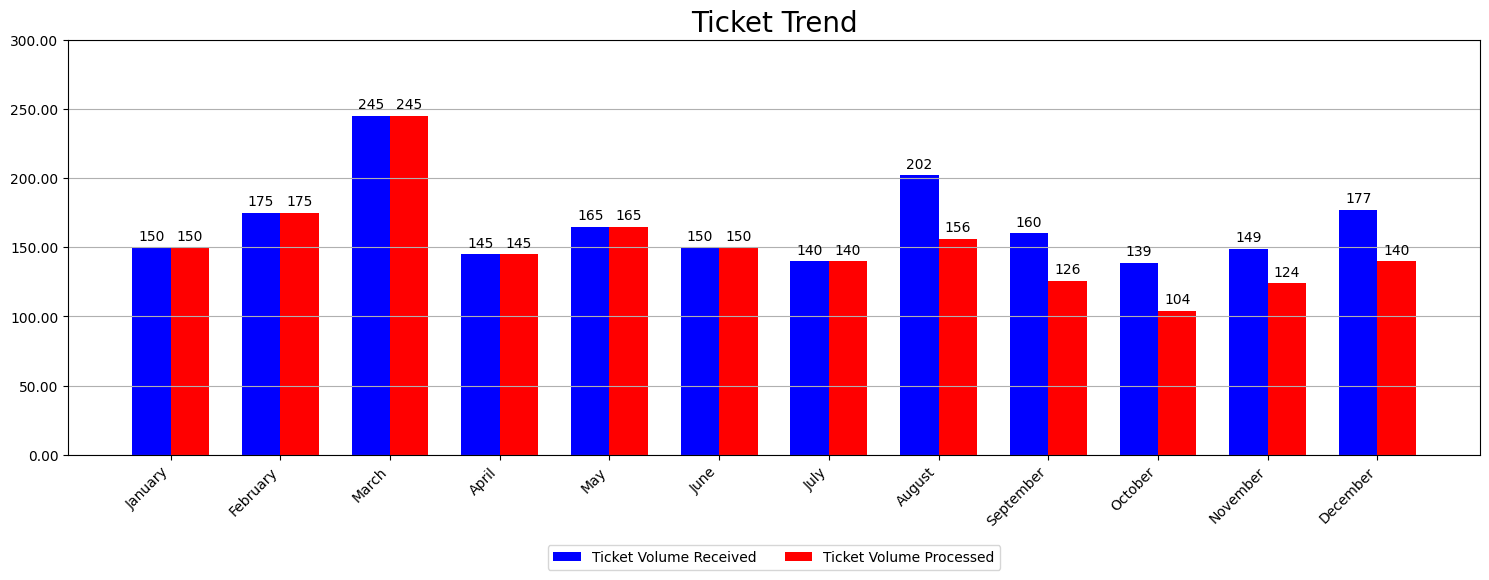

In [58]:
data = {
    "Month": ["January", "February", "March", "April", "May", "June",
              "July", "August", "September", "October", "November", "December"],
    "Received": [150, 175, 245, 145, 165, 150, 140, 202, 160, 139, 149, 177],
    "Processed": [150, 175, 245, 145, 165, 150, 140, 156, 126, 104, 124, 140]}

df = pd.DataFrame(data)

x = np.arange(len(df["Month"]))
width = 0.35
plt.figure(figsize=(15,6))

bars1 = plt.bar(x - width/2, df["Received"], width, color="blue", label="Ticket Volume Received", zorder=1)
bars2 = plt.bar(x + width/2, df["Processed"], width, color="red", label="Ticket Volume Processed", zorder=1)

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 3,
             f"{height}", ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 3,
             f"{height}", ha='center', va='bottom', fontsize=10)

plt.xticks(x, df["Month"], rotation=45, ha='right')
plt.ylim(0, 300)

yticks = np.arange(0, 301, 50)
plt.yticks(yticks, [f"{y:.2f}" for y in yticks])

plt.grid(axis='y', linestyle='-', zorder=0)

plt.title("Ticket Trend", fontsize=20)

plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2)

plt.tight_layout()
plt.show()